In [3]:
import pandas as pd
import numpy as np


In [4]:


cols = ["date", "text"]

df = pd.read_csv("Bitcoin_tweets.csv", usecols=cols)

/var/folders/99/7sjp9rrj0hnbskrtn40bmxlm0000gn/T/ipykernel_2929/2149833329.py:3: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Bitcoin_tweets.csv", usecols=cols)


In [5]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])  # drop rows where date conversion failed

In [6]:
df = df[['date', 'text']]

In [7]:
df.head()

,date,text
0,2021-02-10 23:59:04,Blue Ridge Bank shares halted by NYSE after #b...
1,2021-02-10 23:58:48,"😎 Today, that's this #Thursday, we will do a ""..."
2,2021-02-10 23:54:48,"Guys evening, I have read this article about B..."
3,2021-02-10 23:54:33,$BTC A big chance in a billion! Price: \487264...
4,2021-02-10 23:54:06,This network is secured by 9 508 nodes as of t...


In [8]:
df['date'] = df['date'].dt.date


In [9]:
import yfinance as yf

btc = yf.download("BTC-USD", start="2021-02-01", end="2023-01-10")
btc.reset_index(inplace=True)

btc.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
0,2021-02-01,33537.175781,34638.214844,32384.228516,33114.578125,61400400660
1,2021-02-02,35510.289062,35896.882812,33489.218750,33533.199219,63088585433
2,2021-02-03,37472.089844,37480.187500,35443.984375,35510.820312,61166818159
3,2021-02-04,36926.066406,38592.175781,36317.500000,37475.105469,68838074392
4,2021-02-05,38144.308594,38225.906250,36658.761719,36931.546875,58598066402


In [10]:
btc.columns = btc.columns.get_level_values(0)


In [11]:
btc.head()


Price,Date,Close,High,Low,Open,Volume
0,2021-02-01,33537.175781,34638.214844,32384.228516,33114.578125,61400400660
1,2021-02-02,35510.289062,35896.882812,33489.218750,33533.199219,63088585433
2,2021-02-03,37472.089844,37480.187500,35443.984375,35510.820312,61166818159
3,2021-02-04,36926.066406,38592.175781,36317.500000,37475.105469,68838074392
4,2021-02-05,38144.308594,38225.906250,36658.761719,36931.546875,58598066402


Install & Import Sentiment Model

In [12]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/m2/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [13]:
def get_sentiment(text):
    return sia.polarity_scores(text)['compound']

In [14]:
df['sentiment'] = df['text'].map(get_sentiment)

Aggregate by date:


In [16]:
daily_sentiment = df.groupby(df['date'])['sentiment'].mean()
daily_sentiment = daily_sentiment.reset_index()
daily_sentiment.columns = ['date', 'avg_sentiment']

In [17]:

daily_sentiment.to_csv("daily_sentiment.csv", index=False)

In [18]:
daily_sentiment = pd.read_csv("daily_sentiment.csv")

In [19]:
daily_sentiment.head()


,date,avg_sentiment
0,2021-02-05,0.125521
1,2021-02-06,0.129958
2,2021-02-07,0.139586
3,2021-02-08,0.157370
4,2021-02-09,0.149422


In [20]:
btc.dtypes

Price
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

In [21]:
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'])

In [22]:
daily_sentiment.dtypes

date             datetime64[ns]
avg_sentiment           float64
dtype: object

In [23]:
merged = pd.merge(
    daily_sentiment,
    btc,
    left_on="date",
    right_on="Date"
)

In [24]:
merged.head()

,date,avg_sentiment,Date,Close,High,Low,Open,Volume
0,2021-02-05,0.125521,2021-02-05,38144.308594,38225.906250,36658.761719,36931.546875,58598066402
1,2021-02-06,0.129958,2021-02-06,39266.011719,40846.546875,38138.386719,38138.386719,71326033653
2,2021-02-07,0.139586,2021-02-07,38903.441406,39621.835938,37446.152344,39250.191406,65500641143
3,2021-02-08,0.157370,2021-02-08,46196.464844,46203.929688,38076.324219,38886.828125,101467222687
4,2021-02-09,0.149422,2021-02-09,46481.105469,48003.722656,45166.960938,46184.992188,91809846886


In [25]:
merged = merged.sort_values("date")
merged = merged.reset_index(drop=True)

today’s sentiment predict tomorrow’s price movement?
(Closet+1​−Closet​​)/Closet
(“Store tomorrow’s percentage price change in today’s row.”)

In [26]:
merged['next_day_return'] = merged['Close'].pct_change().shift(-1)

In [27]:
merged.head()

,date,avg_sentiment,Date,Close,High,Low,Open,Volume,next_day_return
0,2021-02-05,0.125521,2021-02-05,38144.308594,38225.906250,36658.761719,36931.546875,58598066402,0.029407
1,2021-02-06,0.129958,2021-02-06,39266.011719,40846.546875,38138.386719,38138.386719,71326033653,-0.009234
2,2021-02-07,0.139586,2021-02-07,38903.441406,39621.835938,37446.152344,39250.191406,65500641143,0.187465
3,2021-02-08,0.157370,2021-02-08,46196.464844,46203.929688,38076.324219,38886.828125,101467222687,0.006162
4,2021-02-09,0.149422,2021-02-09,46481.105469,48003.722656,45166.960938,46184.992188,91809846886,-0.033625


In [28]:
merged=merged.dropna()

In [29]:
merged['target'] = (merged['next_day_return'] > 0).astype(int)

In [30]:
merged['target'].value_counts()

target
1    113
0    108
Name: count, dtype: int64

In [31]:
merged.info()


<class 'pandas.core.frame.DataFrame'>
Index: 221 entries, 0 to 220
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             221 non-null    datetime64[ns]
 1   avg_sentiment    221 non-null    float64       
 2   Date             221 non-null    datetime64[ns]
 3   Close            221 non-null    float64       
 4   High             221 non-null    float64       
 5   Low              221 non-null    float64       
 6   Open             221 non-null    float64       
 7   Volume           221 non-null    int64         
 8   next_day_return  221 non-null    float64       
 9   target           221 non-null    int64         
dtypes: datetime64[ns](2), float64(6), int64(2)
memory usage: 19.0 KB


In [32]:
merged.drop(columns=["date"], inplace=True)

In [33]:
merged.describe()

,avg_sentiment,Date,Close,High,Low,Open,Volume,next_day_return,target
count,221.000000,221,221.000000,221.000000,221.000000,221.000000,2.210000e+02,221.000000,221.000000
mean,0.202492,2022-01-11 16:49:57.285067776,37689.163594,38628.205728,36654.347201,37731.524613,3.760774e+10,-0.001635,0.511312
min,0.073494,2021-02-05 00:00:00,15787.284180,16291.223633,15599.046875,15883.158203,7.714767e+09,-0.255628,0.000000
25%,0.153796,2021-07-27 00:00:00,28627.574219,28814.900391,26350.490234,28622.625000,2.495778e+10,-0.029266,0.000000
50%,0.195931,2022-02-14 00:00:00,39338.785156,40379.617188,38076.324219,39241.429688,3.322523e+10,0.001566,1.000000
75%,0.250638,2022-06-04 00:00:00,46444.710938,47879.964844,45579.589844,46490.605469,4.421984e+10,0.021900,1.000000
max,0.387803,2023-01-08 00:00:00,65992.835938,66930.390625,64180.488281,66002.234375,1.189925e+11,0.381922,1.000000
std,0.061884,NaN,13703.798905,14059.734295,13353.953058,13760.944887,1.864146e+10,0.063412,0.501007


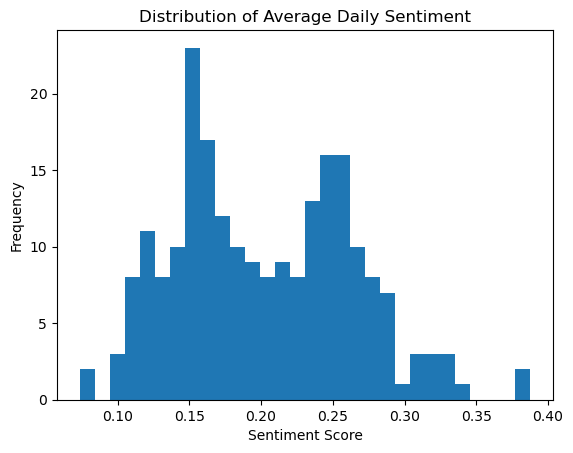

In [34]:
import matplotlib.pyplot as plt

plt.hist(merged['avg_sentiment'], bins=30)
plt.title("Distribution of Average Daily Sentiment")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

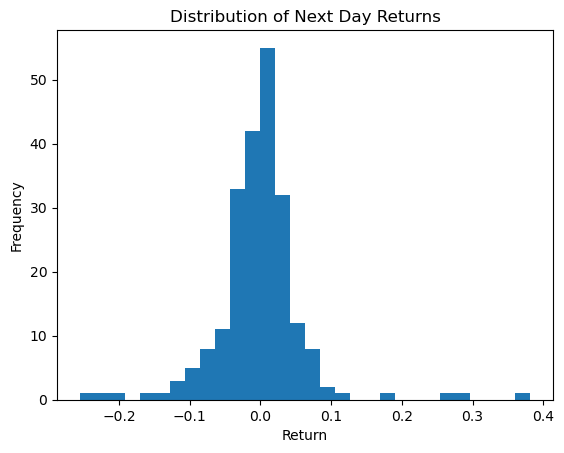

In [35]:
plt.hist(merged['next_day_return'], bins=30)
plt.title("Distribution of Next Day Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

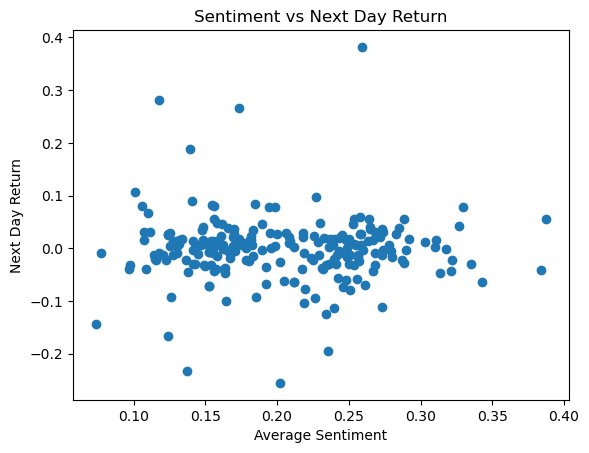

In [36]:
plt.scatter(merged['avg_sentiment'], merged['next_day_return'])
plt.xlabel("Average Sentiment")
plt.ylabel("Next Day Return")
plt.title("Sentiment vs Next Day Return")
plt.show()

In [37]:
merged.sort_values("next_day_return", ascending=False).head(1)

,avg_sentiment,Date,Close,High,Low,Open,Volume,next_day_return,target
77,0.259198,2021-09-10,44883.910156,47031.742188,44344.484375,46396.664062,39154666597,0.381922,1


Correlation WITH outlier

In [38]:
merged[['avg_sentiment', 'next_day_return']].corr()

,avg_sentiment,next_day_return
avg_sentiment,1.000000,-0.021879
next_day_return,-0.021879,1.000000


Correlation WITHOUT extreme moves (>20%)

In [39]:
filtered = merged[merged['next_day_return'].abs() < 0.2]
filtered[['avg_sentiment', 'next_day_return']].corr()

,avg_sentiment,next_day_return
avg_sentiment,1.000000,-0.038158
next_day_return,-0.038158,1.000000


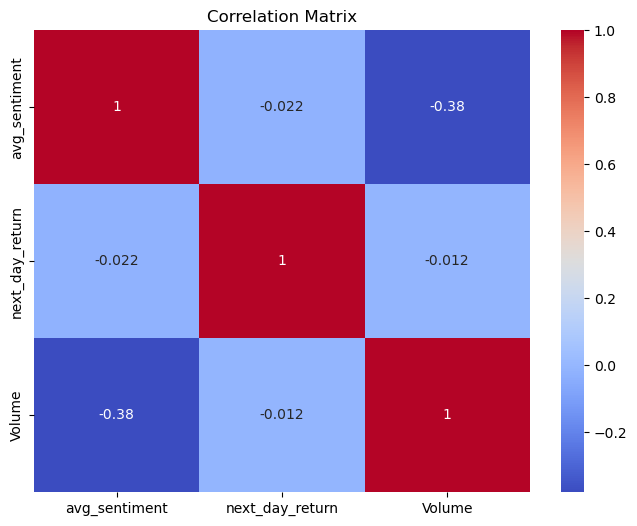

In [40]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    merged[['avg_sentiment', 'next_day_return', 'Volume']].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

Sentiment Over Time


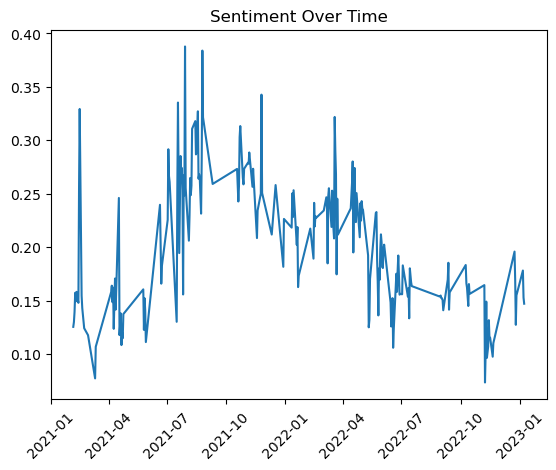

In [41]:
plt.plot(merged['Date'], merged['avg_sentiment'])
plt.title("Sentiment Over Time")
plt.xticks(rotation=45)
plt.show()

BTC Price Over Time

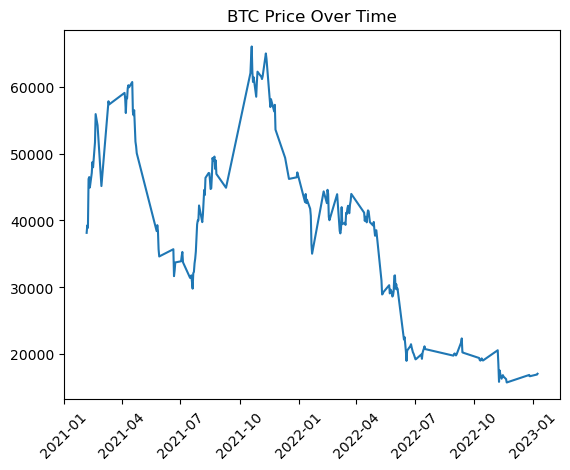

In [42]:
plt.plot(merged['Date'], merged['Close'])
plt.title("BTC Price Over Time")
plt.xticks(rotation=45)
plt.show()

creating  new lag sentiment features to capture delayed reaction


-Day Rolling Sentiment
We compute a 3-day and 7-day moving average of daily sentiment:
This represents the average sentiment over the last three days.
used to capture trend

Measures percentage price change from previous day.  

Measures intraday price fluctuation relative to opening price.  

Measures change in trading activity from previous day.  



In [43]:
merged['return_1d'] = merged['Close'].pct_change()
merged['volatility'] = (merged['High'] - merged['Low']) / merged['Open']
merged['volume_change'] = merged['Volume'].pct_change()

Log Transform to handle volume data

In [44]:
merged['log_volume'] = np.log1p(merged['Volume'])

In [45]:
merged.isnull().sum()

avg_sentiment      0
Date               0
Close              0
High               0
Low                0
Open               0
Volume             0
next_day_return    0
target             0
return_1d          1
volatility         0
volume_change      1
log_volume         0
dtype: int64

In [46]:
merged = merged.dropna()

Define Feature Matrix. 

In [47]:
features = [
    'avg_sentiment',
    'return_1d',
    'volatility',
    'volume_change',
    'log_volume'
]

X = merged[features]
y = merged['target']

Time-Based Train–Test Split

To avoid look-ahead bias, the dataset is split chronologically.

All data before 1 august 2022 is used for training,
and data from 1 august 2022 onward is used for testing.

In [48]:
train = merged[merged['Date'] < '2022-08-01']
test  = merged[merged['Date'] >= '2022-08-01']
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

X_train = train[features]
y_train = train['target']

X_test = test[features]
y_test = test['target']

In [49]:
X_train.head()

,avg_sentiment,return_1d,volatility,volume_change,log_volume
0,0.129958,0.029407,0.071009,0.217208,24.990527
1,0.139586,-0.009234,0.055431,-0.081673,24.905326
2,0.157370,0.187465,0.209007,0.549103,25.343002
3,0.149422,0.006162,0.061422,-0.095177,25.242985
4,0.158262,-0.033625,0.070248,-0.049110,25.192629


MODEL training

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [67]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
y_pred_rf = rf.predict(X_test)

In [69]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.42857142857142855

Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.17      0.23        18
           1       0.44      0.71      0.55        17

    accuracy                           0.43        35
   macro avg       0.41      0.44      0.39        35
weighted avg       0.41      0.43      0.38        35


Confusion Matrix:
 [[ 3 15]
 [ 5 12]]


In [70]:
importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values(ascending=False)

volume_change    0.213864
log_volume       0.213106
avg_sentiment    0.199108
return_1d        0.198977
volatility       0.174945
dtype: float64

In [71]:
from sklearn.linear_model import LogisticRegression

In [72]:
model= LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [73]:
y_prep=model.predict(X_test_scaled)

In [74]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_prep))
print("\nClassification Report:\n", classification_report(y_test, y_prep))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_prep))

Accuracy: 0.42857142857142855

Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.39      0.41        18
           1       0.42      0.47      0.44        17

    accuracy                           0.43        35
   macro avg       0.43      0.43      0.43        35
weighted avg       0.43      0.43      0.43        35


Confusion Matrix:
 [[ 7 11]
 [ 9  8]]


In [75]:
from xgboost import XGBClassifier

In [76]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

In [77]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

/opt/anaconda3/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [23:57:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [78]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.4857142857142857

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.39      0.44        18
           1       0.48      0.59      0.53        17

    accuracy                           0.49        35
   macro avg       0.49      0.49      0.48        35
weighted avg       0.49      0.49      0.48        35


Confusion Matrix:
 [[ 7 11]
 [ 7 10]]


In [79]:
importance = pd.Series(xgb.feature_importances_, index=features)
print(importance.sort_values(ascending=False))

volume_change    0.221989
log_volume       0.202223
avg_sentiment    0.199527
volatility       0.191736
return_1d        0.184524
dtype: float32


In [80]:
import joblib

joblib.dump(xgb, "btc_sentiment_model.pkl")

['btc_sentiment_model.pkl']